<a href="https://colab.research.google.com/github/baquang2910/my-lms/blob/main/RMIT_Pre_class_Insight_2025_AI_Adoption_%26_Sentiment_in_the_Workplace.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [47]:
# Cell 1: Install & Import
!pip install -q openpyxl seaborn plotly

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from pathlib import Path

sns.set(style="whitegrid", font_scale=1.1)
plt.rcParams['figure.figsize'] = (10, 6)

In [48]:
# Cell 2: Load data
FILE_NAME = 'BUSM2676 Leading AI and Workforce Transformation 2025C)GG_Colab.xlsx'

if not Path(FILE_NAME).exists():
    from google.colab import files
    print("Please upload the Excel file")
    uploaded = files.upload()
    FILE_NAME = list(uploaded.keys())[0]

raw = pd.read_excel(FILE_NAME, engine='openpyxl')
print(f"Loaded {len(raw)} responses")
raw.head(2)

Loaded 15 responses


,ID,My company is in this industry,My function in the company is,I have this many years of work experience,"Which of the following AI tools have you used in your workplace? (Select all that apply.) AI tool refers to any digital application, software, or platform that uses artificial intelligence (AI) te...",I am excellent in finance,I am excellent in strategy,I am excellent in marketing,I am excellent in HR,I am a champion in MS Excel,I like to work in teams
0,1,Logistics,Sales,between 6 and 10,"ChatGPT or other generative AI tools (e.g., Ge...",Disagree somewhat,Agree somewhat,Neither agree nor disagree,Strongly disagree,Neither agree nor disagree,Strongly agree
1,2,Healthcare,Marketing,between 1 and 5,"ChatGPT or other generative AI tools (e.g., Ge...",Neither agree nor disagree,Agree somewhat,Neither agree nor disagree,Neither agree nor disagree,Agree somewhat,Neither agree nor disagree


In [49]:
# Cell 3: Feature Engineering

# Main columns
col_ai = [c for c in raw.columns if "Which of the following AI tools" in c][0]
col_industry = 'My company is in this industry'
col_function = 'My function in the company is'
col_exp = 'I have this many years of work experience'

likert_cols = [
    'I am excellent in finance',
    'I am excellent in strategy',
    'I am excellent in marketing',
    'I am excellent in HR ',
    'I am a champion in MS Excel',
    'I like to work in teams'
]

# Parse multiple-choice AI tools
ai_raw_list = raw[col_ai].fillna('').astype(str).apply(
    lambda x: [item.strip() for item in x.split(';') if item.strip()]
)

# Category mapping
categories = {
    'ChatGPT or other generative AI tools (e.g., Gemini, Claude, Copilot)': 'GenAI',
    'AI-assisted writing or editing tools (e.g., Grammarly, Quillbot)': 'WritingAI',
    'AI tools for design or media creation (e.g., Canva Magic Studio, DALL·E, Midjourney)': 'DesignAI',
    'AI-based data analytics or visualization tools (e.g., Power BI, Tableau with AI features)': 'DataAI',
    'AI tools for coding or development (e.g., GitHub Copilot, CodeWhisperer)': 'CodeAI',
    'AI-powered customer service/chatbot tools (e.g., Zendesk AI, Intercom, Drift)': 'CSChatAI',
    'Not using any AI tools': 'NoAI',
    'I use almost all': 'UseAll'
}

df = raw.copy()
for full_name, short in categories.items():
    df[short] = ai_raw_list.apply(lambda lst: full_name in lst).astype(int)

# Likert → numeric
likert_map = {
    'Strongly disagree': -2,
    'Disagree somewhat': -1,
    'Neither agree nor disagree': 0,
    'Agree somewhat': 1,
    'Strongly agree': 2
}

for c in likert_cols:
    df[c + '_num'] = df[c].map(likert_map)

df['AI_Sentiment_Index'] = df[[c + '_num' for c in likert_cols]].mean(axis=1)

# AI Intensity
ai_tool_cols = ['GenAI','WritingAI','DesignAI','DataAI','CodeAI','CSChatAI']

df['AI_Intensity_Raw'] = df[ai_tool_cols].sum(axis=1)

# Final intensity
df['AI_Intensity'] = df['AI_Intensity_Raw']
df.loc[df['NoAI'] == 1, 'AI_Intensity'] = 0
df.loc[df['UseAll'] == 1, 'AI_Intensity'] = len(ai_tool_cols)  # 6

# Experience bucket
def exp_bucket(y):
    if pd.isna(y): return 'Unknown'
    if 'less than 1' in str(y) or 'between 1 and 5' in str(y): return '≤5 years'
    return '>5 years'

df['Experience_Group'] = df[col_exp].apply(exp_bucket)

print("Data ready!")
df[['AI_Sentiment_Index', 'AI_Intensity', 'NoAI', 'UseAll'] + ai_tool_cols].head()

Data ready!


,AI_Sentiment_Index,AI_Intensity,NoAI,UseAll,GenAI,WritingAI,DesignAI,DataAI,CodeAI,CSChatAI
0,0.000000,3,0,0,1,1,1,0,0,0
1,0.333333,2,0,0,1,0,1,0,0,0
2,0.333333,3,0,0,1,1,1,0,0,0
3,0.666667,3,0,0,1,0,1,1,0,0
4,0.333333,3,0,0,1,1,1,0,0,0


In [50]:
# Cell 4: Key Summary Numbers
n = len(df)
print(f"Total respondents: {n}\n")

print("AI Adoption Overview")
print(df['AI_Intensity'].value_counts().sort_index().to_string())

print("\nAverage AI Intensity:", round(df['AI_Intensity'].mean(), 2))
print("Average Sentiment Index:", round(df['AI_Sentiment_Index'].mean(), 2))

Total respondents: 15

AI Adoption Overview
AI_Intensity
0    2
1    2
2    3
3    7
6    1

Average AI Intensity: 2.33
Average Sentiment Index: 0.23


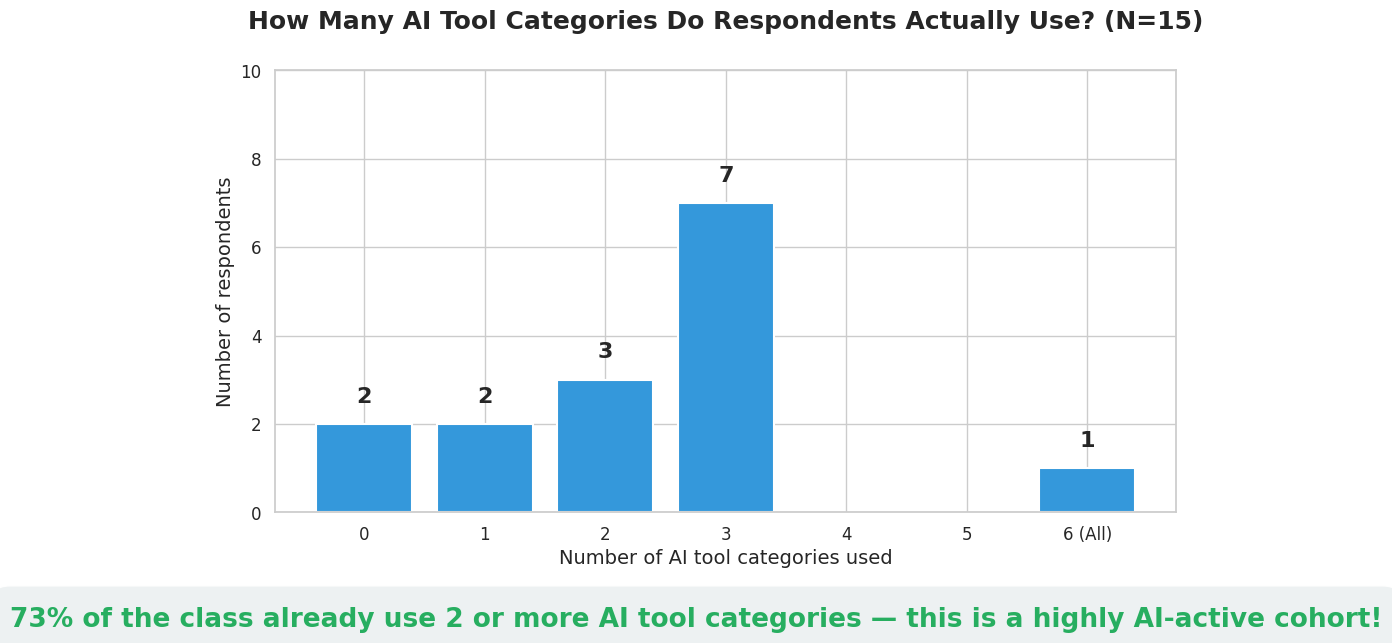

In [51]:
# Cell 5: Stacked Adoption Overview
intensity_counts = df['AI_Intensity'].value_counts().sort_index()
labels = [f"{i} tool category" if i!=1 else "1 tool category" for i in intensity_counts.index]
if 6 in intensity_counts.index:
    labels[-1] = "All 6 categories"

plt.figure(figsize=(10, 6.5))
bars = plt.bar(intensity_counts.index, intensity_counts.values, color='#3498DB', edgecolor='white', linewidth=1.5)

plt.title(f'How Many AI Tool Categories Do Respondents Actually Use? (N={n})',
          fontsize=18, fontweight='bold', pad=30)
plt.xlabel('Number of AI tool categories used', fontsize=14)
plt.ylabel('Number of respondents', fontsize=14)
plt.xticks(range(0, 7), ['0', '1', '2', '3', '4', '5', '6 (All)'], fontsize=12)
plt.ylim(0, intensity_counts.max() + 3)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.4,
             int(height), ha='center', va='bottom', fontweight='bold', fontsize=16)

plt.figtext(0.5, 0.02,
            '73% of the class already use 2 or more AI tool categories — '
            'this is a highly AI-active cohort!',
            ha='center', fontsize=19, fontweight='bold', color='#27AE60',
            bbox=dict(boxstyle="round,pad=0.8", facecolor='#ECF0F1', alpha=0.9))

plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()

In [52]:
# Cell 6 – Scatter Chart

import plotly.express as px

n = len(df)
corr = round(df['AI_Intensity'].corr(df['AI_Sentiment_Index']), 3)

fig = px.scatter(
    df,
    x='AI_Intensity',
    y='AI_Sentiment_Index',
    color=col_function,
    size='AI_Intensity',
    hover_data=[col_industry, col_exp],
    color_discrete_sequence=px.colors.qualitative.Bold,
    width=1200,
    height=780
)

fig.update_layout(
    title=f"<b>AI Tool Usage vs Self-Confidence in This Class</b><br>N = {n} respondents | Correlation r = {corr}",
    title_font_size=30,
    title_x=0.5,
    font_size=16,
    legend=dict(title="Function", orientation="v", y=1, x=1.02,
                bgcolor="rgba(255,255,255,0.95)", bordercolor="gray"),
    margin=dict(l=80, r=250, t=120, b=100)
)

fig.add_hline(y=0, line_dash="dash", line_color="gray")
fig.update_traces(marker=dict(line=dict(width=3, color='white')))

fig.show()

print("\n" + "="*100)
print("INSIGHT:")
print("More AI tools used → slightly higher self-confidence")
print("But the link is weak — mindset & experience matter far more than tool count")
print("="*100 + "\n")


INSIGHT:
More AI tools used → slightly higher self-confidence
But the link is weak — mindset & experience matter far more than tool count



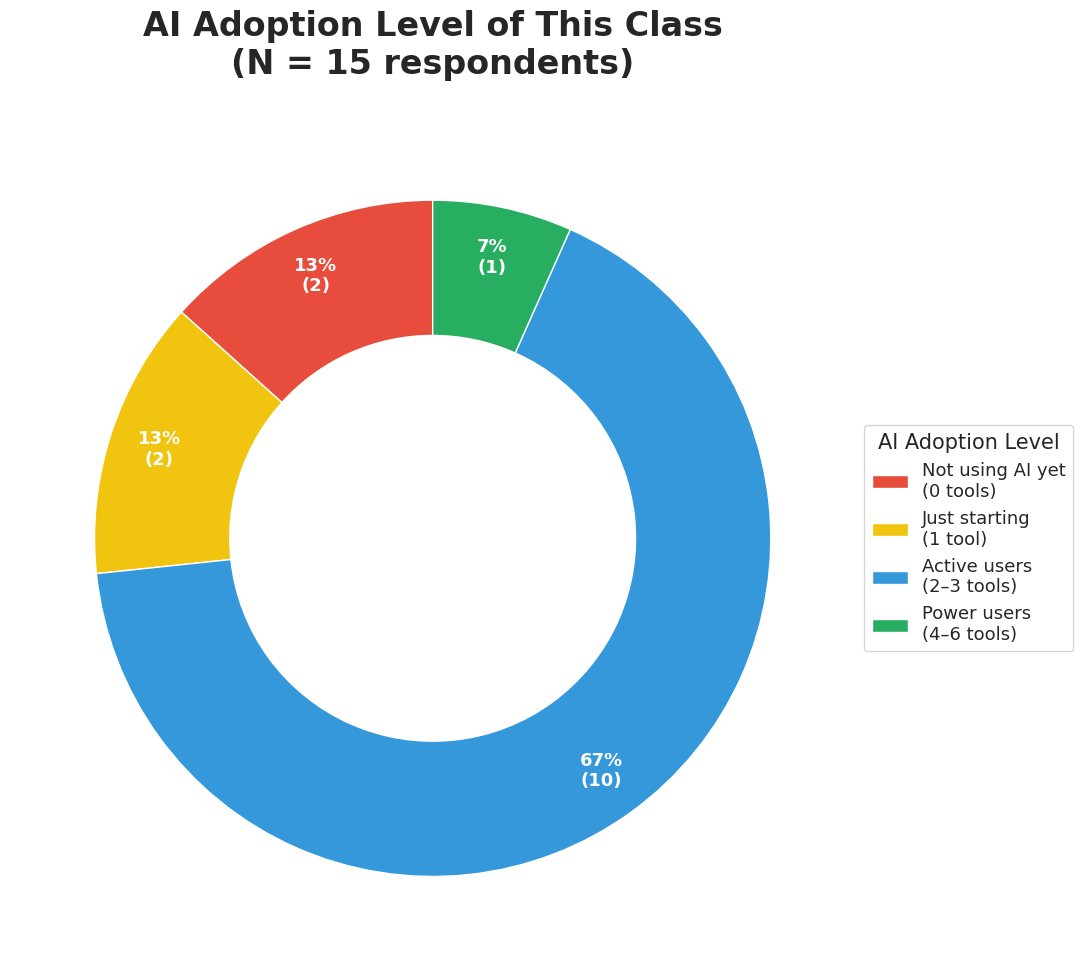

In [53]:
# Cell 7 – DONUT CHART
import matplotlib.pyplot as plt

n = len(df)

# Data
sizes = [
    (df['AI_Intensity'] == 0).sum(),
    (df['AI_Intensity'] == 1).sum(),
    ((df['AI_Intensity'] >= 2) & (df['AI_Intensity'] <= 3)).sum(),
    (df['AI_Intensity'] >= 4).sum()
]

labels = ['Not using AI yet', 'Just starting', 'Active users', 'Power users']
sub_labels = ['(0 tools)', '(1 tool)', '(2–3 tools)', '(4–6 tools)']
colors = ['#E74C3C', '#F1C40F', '#3498DB', '#27AE60']

fig, ax = plt.subplots(figsize=(11, 11))
wedges, texts, autotexts = ax.pie(
    sizes,
    labels=None,
    colors=colors,
    autopct=lambda pct: f'{pct:.0f}%\n({int(pct/100*n)})' if pct >= 5 else '',
    startangle=90,
    wedgeprops=dict(width=0.4, edgecolor='white'),
    pctdistance=0.85
)

legend_labels = [f'{label}\n{sub}' for label, sub in zip(labels, sub_labels)]
ax.legend(
    wedges,
    legend_labels,
    title="AI Adoption Level",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1),
    fontsize=13,
    title_fontsize=15
)

for autotext in autotexts:
    if autotext.get_text():
        autotext.set_color('white')
        autotext.set_fontweight('bold')
        autotext.set_fontsize(13)

ax.set_title(f'AI Adoption Level of This Class\n(N = {n} respondents)',
             fontsize=24, fontweight='bold', pad=30)

plt.tight_layout()
plt.show()

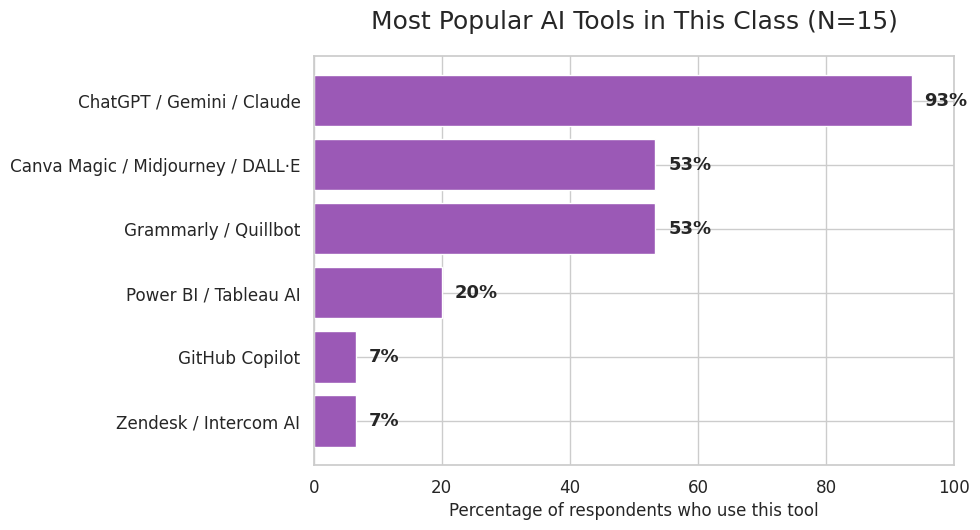

In [54]:
# Cell 8 – CHART of Most Popular AI Tools
tool_names = {
    'GenAI': 'ChatGPT / Gemini / Claude',
    'WritingAI': 'Grammarly / Quillbot',
    'DesignAI': 'Canva Magic / Midjourney / DALL·E',
    'DataAI': 'Power BI / Tableau AI',
    'CodeAI': 'GitHub Copilot',
    'CSChatAI': 'Zendesk / Intercom AI'
}

tool_usage = df[ai_tool_cols].mean().sort_values(ascending=True) * 100

plt.figure(figsize=(10, 5.5))
bars = plt.barh(range(len(tool_usage)), tool_usage.values, color='#9B59B6', edgecolor='white')
plt.yticks(range(len(tool_usage)), [tool_names[col] for col in tool_usage.index])
plt.xlim(0, 100)
plt.xlabel('Percentage of respondents who use this tool', fontsize=12)
plt.title(f'Most Popular AI Tools in This Class (N={n})', fontsize=18, pad=20)

for i, bar in enumerate(bars):
    width = bar.get_width()
    plt.text(width + 2, bar.get_y() + bar.get_height()/2,
             f'{width:.0f}%', va='center', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

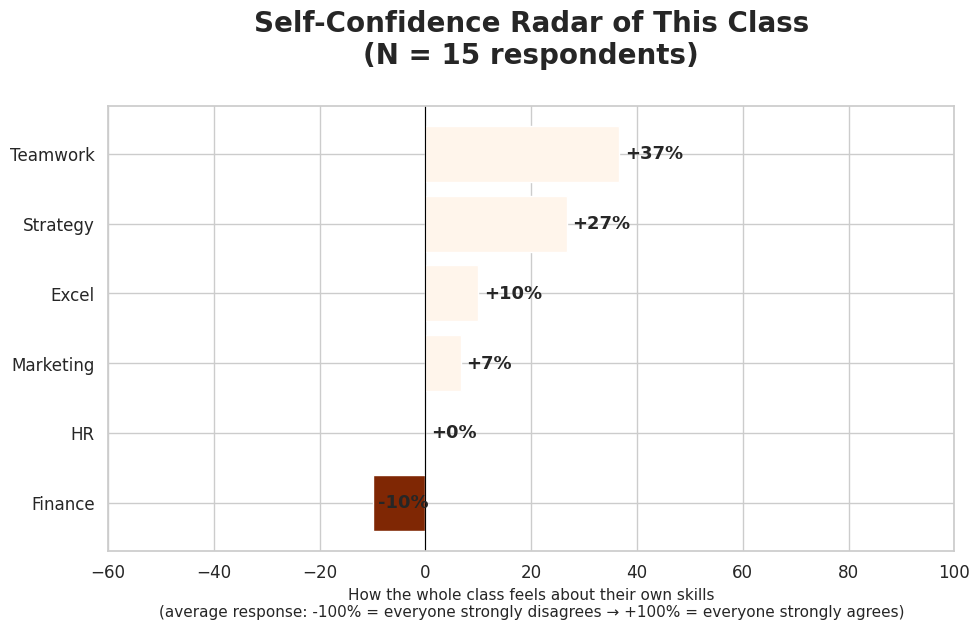

Most confident → Teamwork (+37%)
Least confident → Finance (-10%)


In [55]:
# Cell 9

skill_questions = {
    'I am excellent in finance_num': 'Finance',
    'I am excellent in strategy_num': 'Strategy',
    'I am excellent in marketing_num': 'Marketing',
    'I am excellent in HR _num': 'HR',
    'I am a champion in MS Excel_num': 'Excel',
    'I like to work in teams_num': 'Teamwork'
}

confidence = df[list(skill_questions.keys())].replace({-2:-1, -1:-0.5, 1:0.5, 2:1})
avg_confidence = confidence.mean() * 100

order = avg_confidence.sort_values(ascending=True)

plt.figure(figsize=(10, 6.5))

colors = plt.cm.Oranges_r((order.values + 2) / 4)

bars = plt.barh(order.index.map(skill_questions), order.values, color=colors, edgecolor='white')

for i, (skill, val) in enumerate(order.items()):
    plt.text(val + 1, i, f'{val:+.0f}%', va='center', fontweight='bold', fontsize=13)

plt.axvline(0, color='black', linewidth=0.8)

plt.xlabel('How the whole class feels about their own skills\n(average response: -100% = everyone strongly disagrees → +100% = everyone strongly agrees)',
           fontsize=11)
plt.title(f'Self-Confidence Radar of This Class\n'
          f'(N = {n} respondents)', fontsize=20, fontweight='bold', pad=30)
plt.xlim(-60, 100)
plt.tight_layout()
plt.show()

# Summary
print("Most confident →", skill_questions[order.index[-1]], f"(+{order.iloc[-1]:.0f}%)")
print("Least confident →", skill_questions[order.index[0]],  f"({order.iloc[0]:+.0f}%)")